In [63]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

In [64]:
df = pd.read_csv('../data/oasis_longitudinal.csv')
df.head()

,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [65]:
df.isnull().sum() / len(df) * 100

Subject ID    0.000000
MRI ID        0.000000
Group         0.000000
Visit         0.000000
MR Delay      0.000000
M/F           0.000000
Hand          0.000000
Age           0.000000
EDUC          0.000000
SES           5.093834
MMSE          0.536193
CDR           0.000000
eTIV          0.000000
nWBV          0.000000
ASF           0.000000
dtype: float64

<Axes: xlabel='Group'>

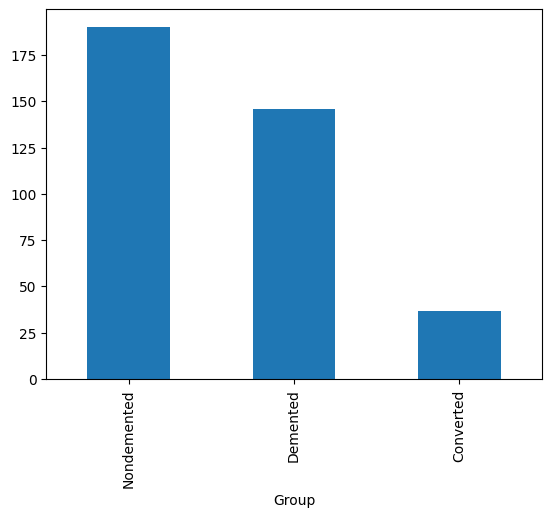

In [66]:
df['Group'].value_counts()      
df['Group'].value_counts(normalize=True)  
df['Group'].value_counts().plot(kind='bar')  

In [67]:
df.describe()                    #
df.describe().T  

,count,mean,std,min,25%,50%,75%,max
Visit,373.0,1.882038,0.922843,1.000,1.000,2.000,2.000,5.000
MR Delay,373.0,595.104558,635.485118,0.000,0.000,552.000,873.000,2639.000
Age,373.0,77.013405,7.640957,60.000,71.000,77.000,82.000,98.000
EDUC,373.0,14.597855,2.876339,6.000,12.000,15.000,16.000,23.000
SES,354.0,2.460452,1.134005,1.000,2.000,2.000,3.000,5.000
MMSE,371.0,27.342318,3.683244,4.000,27.000,29.000,30.000,30.000
CDR,373.0,0.290885,0.374557,0.000,0.000,0.000,0.500,2.000
eTIV,373.0,1488.128686,176.139286,1106.000,1357.000,1470.000,1597.000,2004.000
nWBV,373.0,0.729568,0.037135,0.644,0.700,0.729,0.756,0.837
ASF,373.0,1.195461,0.138092,0.876,1.099,1.194,1.293,1.587


In [68]:
print(df[['MMSE', 'SES']].isnull().sum())
print(df[['MMSE', 'SES']].isnull().sum() / len(df) * 100)

MMSE     2
SES     19
dtype: int64
MMSE    0.536193
SES     5.093834
dtype: float64


<Axes: >

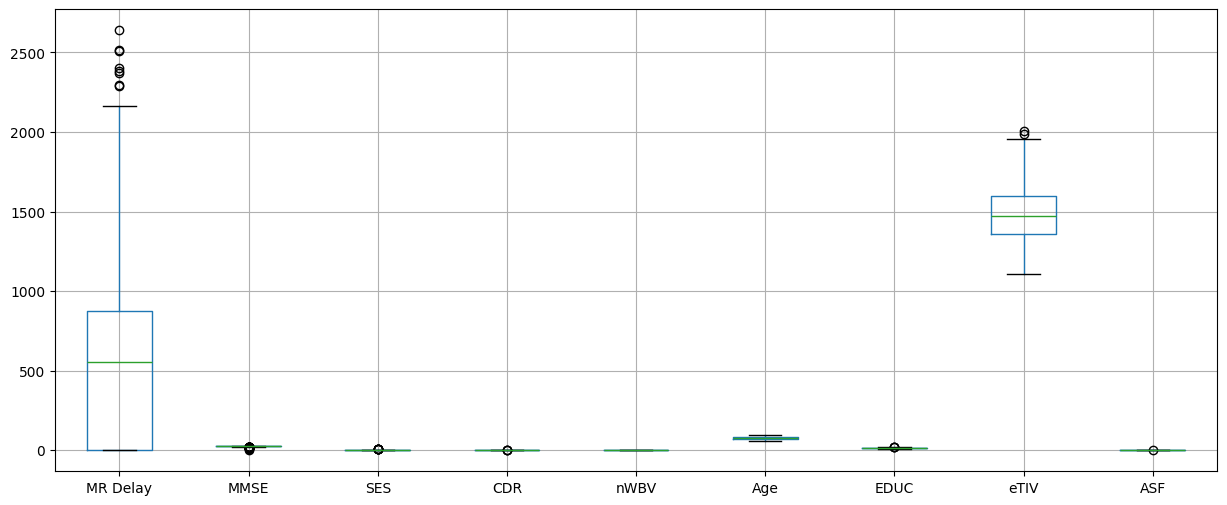

In [69]:
df.boxplot(column=['MR Delay','MMSE', 'SES', 'CDR', 'nWBV', 'Age', 'EDUC', 'eTIV', 'ASF'], figsize=(15,6))

In [70]:
df['MR Delay (Years)'] = df['MR Delay'] / 365.25
df = df.drop(columns=[ 'MRI ID','MR Delay' , 'Hand'], axis=1)

In [71]:
df


,Subject ID,Group,Visit,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,MR Delay (Years)
0,OAS2_0001,Nondemented,1,M,87,14,2.0,27.0,0.0,1987,0.696,0.883,0.000000
1,OAS2_0001,Nondemented,2,M,88,14,2.0,30.0,0.0,2004,0.681,0.876,1.251198
2,OAS2_0002,Demented,1,M,75,12,NaN,23.0,0.5,1678,0.736,1.046,0.000000
3,OAS2_0002,Demented,2,M,76,12,NaN,28.0,0.5,1738,0.713,1.010,1.533196
4,OAS2_0002,Demented,3,M,80,12,NaN,22.0,0.5,1698,0.701,1.034,5.188227
...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,Demented,2,M,82,16,1.0,28.0,0.5,1693,0.694,1.037,2.305270
369,OAS2_0185,Demented,3,M,86,16,1.0,26.0,0.5,1688,0.675,1.040,6.288843
370,OAS2_0186,Nondemented,1,F,61,13,2.0,30.0,0.0,1319,0.801,1.331,0.000000
371,OAS2_0186,Nondemented,2,F,63,13,2.0,30.0,0.0,1327,0.796,1.323,2.088980


In [72]:
# Final audit
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)
print(df.head())
df

(373, 13)
Subject ID           0
Group                0
Visit                0
M/F                  0
Age                  0
EDUC                 0
SES                 19
MMSE                 2
CDR                  0
eTIV                 0
nWBV                 0
ASF                  0
MR Delay (Years)     0
dtype: int64
Subject ID           object
Group                object
Visit                 int64
M/F                  object
Age                   int64
EDUC                  int64
SES                 float64
MMSE                float64
CDR                 float64
eTIV                  int64
nWBV                float64
ASF                 float64
MR Delay (Years)    float64
dtype: object
  Subject ID        Group  Visit M/F  Age  EDUC  SES  MMSE  CDR  eTIV   nWBV  \
0  OAS2_0001  Nondemented      1   M   87    14  2.0  27.0  0.0  1987  0.696   
1  OAS2_0001  Nondemented      2   M   88    14  2.0  30.0  0.0  2004  0.681   
2  OAS2_0002     Demented      1   M   75    12  NaN  23.0  

,Subject ID,Group,Visit,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,MR Delay (Years)
0,OAS2_0001,Nondemented,1,M,87,14,2.0,27.0,0.0,1987,0.696,0.883,0.000000
1,OAS2_0001,Nondemented,2,M,88,14,2.0,30.0,0.0,2004,0.681,0.876,1.251198
2,OAS2_0002,Demented,1,M,75,12,NaN,23.0,0.5,1678,0.736,1.046,0.000000
3,OAS2_0002,Demented,2,M,76,12,NaN,28.0,0.5,1738,0.713,1.010,1.533196
4,OAS2_0002,Demented,3,M,80,12,NaN,22.0,0.5,1698,0.701,1.034,5.188227
...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,Demented,2,M,82,16,1.0,28.0,0.5,1693,0.694,1.037,2.305270
369,OAS2_0185,Demented,3,M,86,16,1.0,26.0,0.5,1688,0.675,1.040,6.288843
370,OAS2_0186,Nondemented,1,F,61,13,2.0,30.0,0.0,1319,0.801,1.331,0.000000
371,OAS2_0186,Nondemented,2,F,63,13,2.0,30.0,0.0,1327,0.796,1.323,2.088980


In [73]:
df


,Subject ID,Group,Visit,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,MR Delay (Years)
0,OAS2_0001,Nondemented,1,M,87,14,2.0,27.0,0.0,1987,0.696,0.883,0.000000
1,OAS2_0001,Nondemented,2,M,88,14,2.0,30.0,0.0,2004,0.681,0.876,1.251198
2,OAS2_0002,Demented,1,M,75,12,NaN,23.0,0.5,1678,0.736,1.046,0.000000
3,OAS2_0002,Demented,2,M,76,12,NaN,28.0,0.5,1738,0.713,1.010,1.533196
4,OAS2_0002,Demented,3,M,80,12,NaN,22.0,0.5,1698,0.701,1.034,5.188227
...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,Demented,2,M,82,16,1.0,28.0,0.5,1693,0.694,1.037,2.305270
369,OAS2_0185,Demented,3,M,86,16,1.0,26.0,0.5,1688,0.675,1.040,6.288843
370,OAS2_0186,Nondemented,1,F,61,13,2.0,30.0,0.0,1319,0.801,1.331,0.000000
371,OAS2_0186,Nondemented,2,F,63,13,2.0,30.0,0.0,1327,0.796,1.323,2.088980


In [74]:
df['baseline_CDR'] = df.groupby('Subject ID')['CDR'].transform('first')
df

,Subject ID,Group,Visit,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,MR Delay (Years),baseline_CDR
0,OAS2_0001,Nondemented,1,M,87,14,2.0,27.0,0.0,1987,0.696,0.883,0.000000,0.0
1,OAS2_0001,Nondemented,2,M,88,14,2.0,30.0,0.0,2004,0.681,0.876,1.251198,0.0
2,OAS2_0002,Demented,1,M,75,12,NaN,23.0,0.5,1678,0.736,1.046,0.000000,0.5
3,OAS2_0002,Demented,2,M,76,12,NaN,28.0,0.5,1738,0.713,1.010,1.533196,0.5
4,OAS2_0002,Demented,3,M,80,12,NaN,22.0,0.5,1698,0.701,1.034,5.188227,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,OAS2_0185,Demented,2,M,82,16,1.0,28.0,0.5,1693,0.694,1.037,2.305270,0.5
369,OAS2_0185,Demented,3,M,86,16,1.0,26.0,0.5,1688,0.675,1.040,6.288843,0.5
370,OAS2_0186,Nondemented,1,F,61,13,2.0,30.0,0.0,1319,0.801,1.331,0.000000,0.0
371,OAS2_0186,Nondemented,2,F,63,13,2.0,30.0,0.0,1327,0.796,1.323,2.088980,0.0
